# Univariate Exploratory Data Analysis (EDA)

This notebook contains a thorough and in-depth **Univariate Analysis** on our processed delivery platform datasets (`master_orders.csv` and `customer_features.csv`). 

### Objectives:
1. **Analyze individual variable distributions** to identify skewness, spread, central tendency, and anomalies.
2. **Examine categorical proportions** to understand user demographics, platform choices, and vendor splits.
3. **Investigate operational friction indicators** (such as delay times and order inaccuracies) and customer satisfaction (ratings).
4. **Assess behavioral customer retention** and recency profiles to lay the groundwork for bivariate cohort and survival analysis.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set seaborn style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11

# Ensure figures folder exists
os.makedirs('../report/figures', exist_ok=True)

## 1. Load Processed Datasets

In [2]:
# Load data
orders = pd.read_csv('../data/processed/master_orders.csv')
customers = pd.read_csv('../data/processed/customer_features.csv')

# Parse dates
orders['order_date'] = pd.to_datetime(orders['order_date'])
customers['signup_date'] = pd.to_datetime(customers['signup_date'])
customers['latest_order_date'] = pd.to_datetime(customers['latest_order_date'])

print(f"Master Orders dataset contains {orders.shape[0]} rows and {orders.shape[1]} columns.")
print(f"Customer Features dataset contains {customers.shape[0]} rows and {customers.shape[1]} columns.")

Master Orders dataset contains 73022 rows and 30 columns.
Customer Features dataset contains 5000 rows and 27 columns.


## 2. Quantitative Variable Analysis: Orders

### A. Order Value & Net Spend
First, we analyze `order_value_usd` and `net_value_usd` (order value minus discounts). Since delivery platforms frequently have a high volume of small orders and a few extremely large orders (right-skewed), we will compare the raw distributions and log-transformed distributions to evaluate skewness.

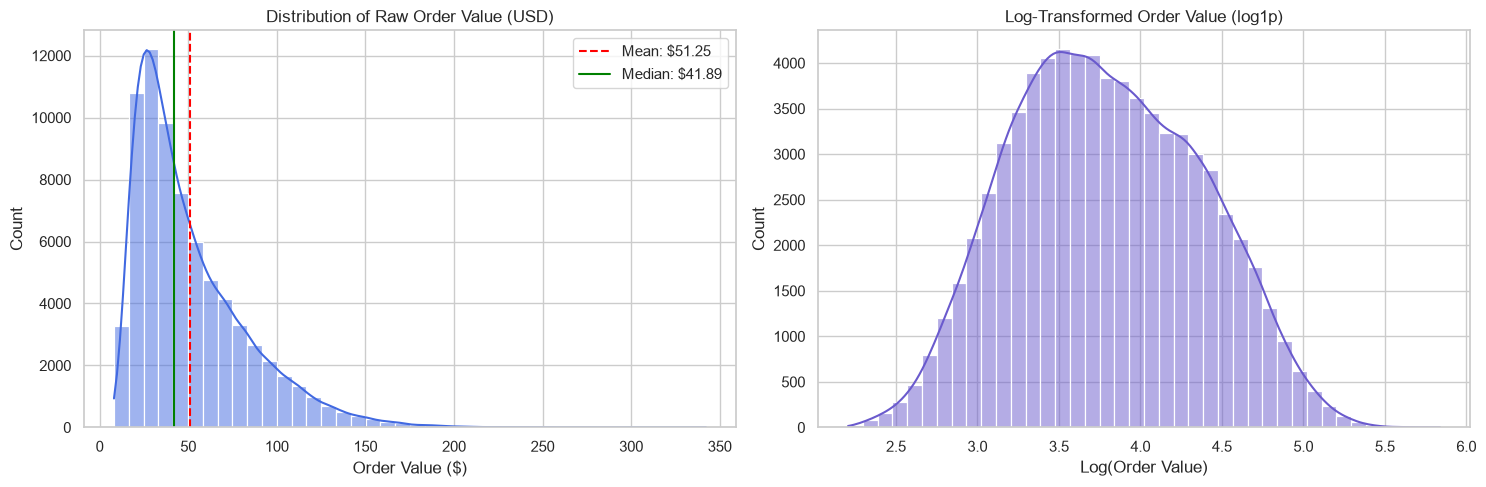

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Raw Order Value distribution
sns.histplot(orders['order_value_usd'], bins=40, kde=True, ax=axes[0], color='royalblue')
axes[0].set_title('Distribution of Raw Order Value (USD)')
axes[0].set_xlabel('Order Value ($)')
axes[0].axvline(orders['order_value_usd'].mean(), color='red', linestyle='--', label=f"Mean: ${orders['order_value_usd'].mean():.2f}")
axes[0].axvline(orders['order_value_usd'].median(), color='green', linestyle='-', label=f"Median: ${orders['order_value_usd'].median():.2f}")
axes[0].legend()

# Log-transformed Order Value distribution
sns.histplot(np.log1p(orders['order_value_usd']), bins=40, kde=True, ax=axes[1], color='slateblue')
axes[1].set_title('Log-Transformed Order Value (log1p)')
axes[1].set_xlabel('Log(Order Value)')

plt.tight_layout()
plt.savefig('../report/figures/univariate_order_value.png', dpi=300)
plt.show()

### B. Items Count & Promo Discounts
Next, we examine the `items_count` per order and the `discount_amount_usd` when promotions are used.

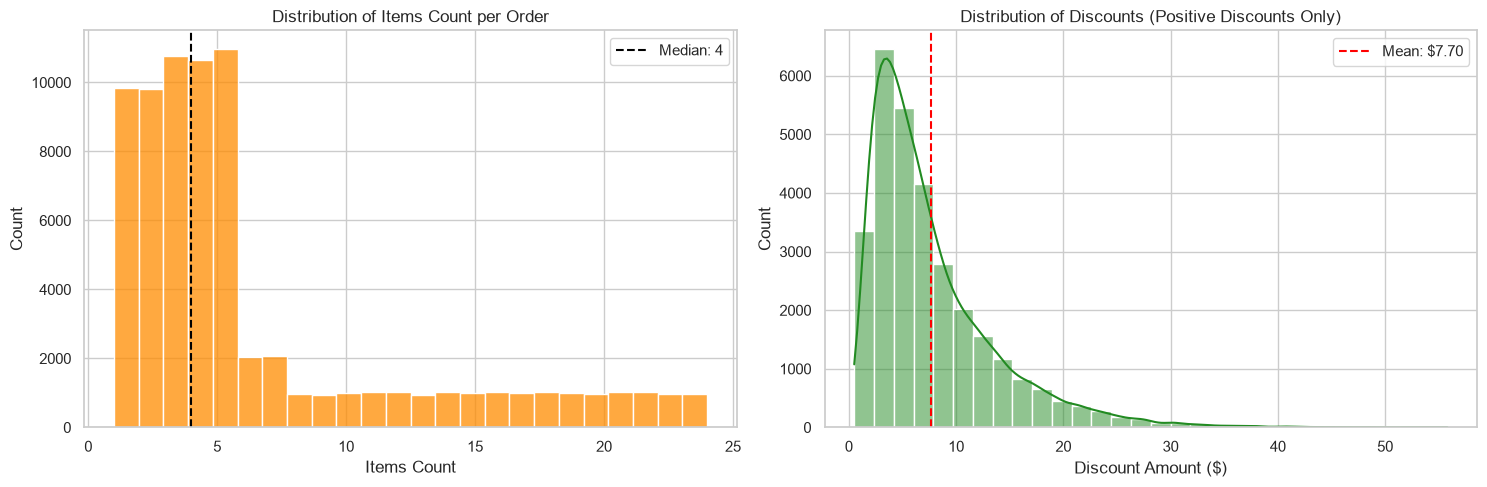

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Items Count
sns.histplot(orders['items_count'], bins=24, kde=False, ax=axes[0], color='darkorange')
axes[0].set_title('Distribution of Items Count per Order')
axes[0].set_xlabel('Items Count')
axes[0].axvline(orders['items_count'].median(), color='black', linestyle='--', label=f"Median: {orders['items_count'].median():.0f}")
axes[0].legend()

# Discount Amount (Only for orders with discounts)
positive_discounts = orders[orders['discount_amount_usd'] > 0]['discount_amount_usd']
sns.histplot(positive_discounts, bins=30, kde=True, ax=axes[1], color='forestgreen')
axes[1].set_title('Distribution of Discounts (Positive Discounts Only)')
axes[1].set_xlabel('Discount Amount ($)')
axes[1].axvline(positive_discounts.mean(), color='red', linestyle='--', label=f"Mean: ${positive_discounts.mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('../report/figures/univariate_items_discount.png', dpi=300)
plt.show()

## 3. Quantitative Variable Analysis: Delivery Performance

### A. Delay Minutes & Delivery Status
Delivery performance is key to retention. Here, we analyze the distribution of `delay_minutes` (for delayed orders) and look at the cumulative distribution (CDF) to see the probability of delays exceeding certain thresholds.

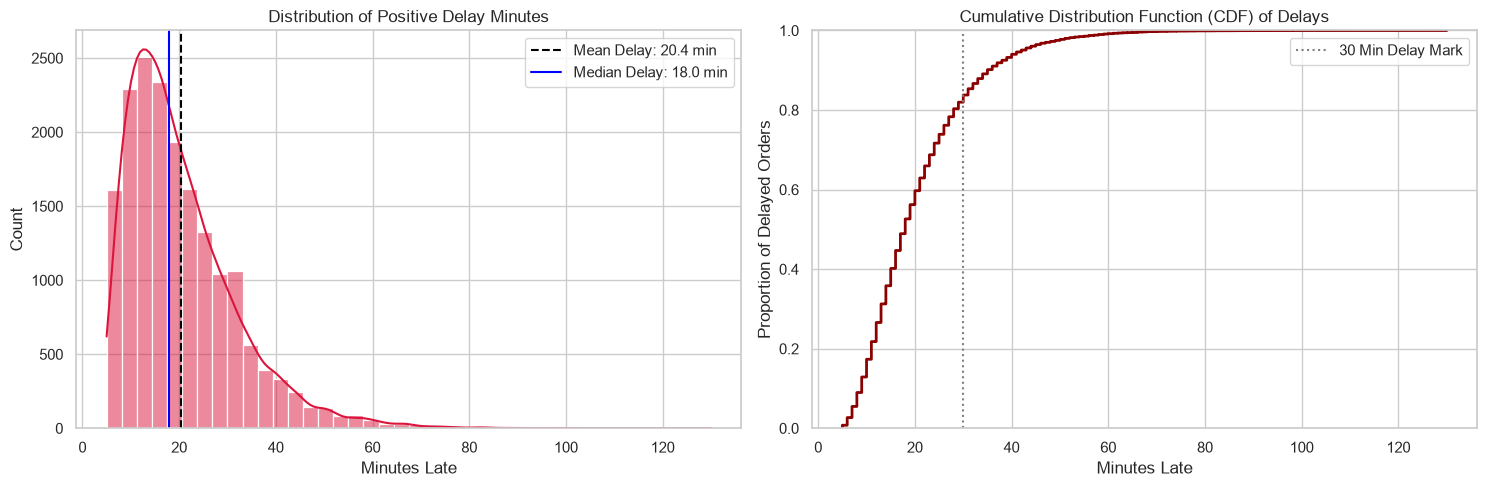

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Probability Density of delays
positive_delays = orders[orders['delay_minutes'] > 0]['delay_minutes']
sns.histplot(positive_delays, bins=40, kde=True, ax=axes[0], color='crimson')
axes[0].set_title('Distribution of Positive Delay Minutes')
axes[0].set_xlabel('Minutes Late')
axes[0].axvline(positive_delays.mean(), color='black', linestyle='--', label=f"Mean Delay: {positive_delays.mean():.1f} min")
axes[0].axvline(positive_delays.median(), color='blue', linestyle='-', label=f"Median Delay: {positive_delays.median():.1f} min")
axes[0].legend()

# Cumulative Distribution of delays
sns.ecdfplot(positive_delays, ax=axes[1], color='darkred', linewidth=2)
axes[1].set_title('Cumulative Distribution Function (CDF) of Delays')
axes[1].set_xlabel('Minutes Late')
axes[1].set_ylabel('Proportion of Delayed Orders')
axes[1].axvline(30, color='gray', linestyle=':', label='30 Min Delay Mark')
axes[1].legend()

plt.tight_layout()
plt.savefig('../report/figures/univariate_delays_cdf.png', dpi=300)
plt.show()

### B. Promised vs Actual Delivery Duration
We compare the distributions of `promised_time_min` against `actual_time_min` to see if promised times are aggressive or conservative.

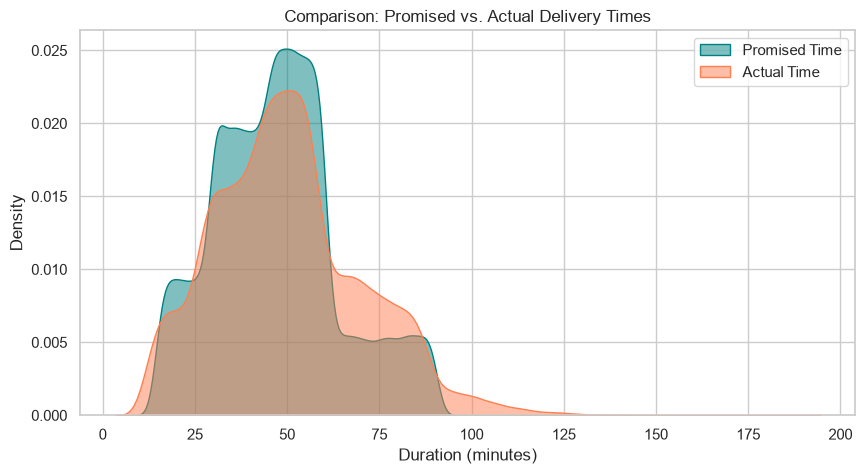

In [6]:
plt.figure(figsize=(10, 5))
sns.kdeplot(orders['promised_time_min'], fill=True, label='Promised Time', color='teal', alpha=0.5)
sns.kdeplot(orders['actual_time_min'], fill=True, label='Actual Time', color='coral', alpha=0.5)
plt.title('Comparison: Promised vs. Actual Delivery Times')
plt.xlabel('Duration (minutes)')
plt.ylabel('Density')
plt.legend()
plt.savefig('../report/figures/univariate_promised_actual_comp.png', dpi=300)
plt.show()

## 4. Quantitative Variable Analysis: Customer Engagement

### A. Order Frequency & Customer Lifetime Spend
We aggregate data at the customer level to evaluate `frequency` (orders per customer) and `total_spend` (total dollar spend). This gives us insights into customer value segment patterns.

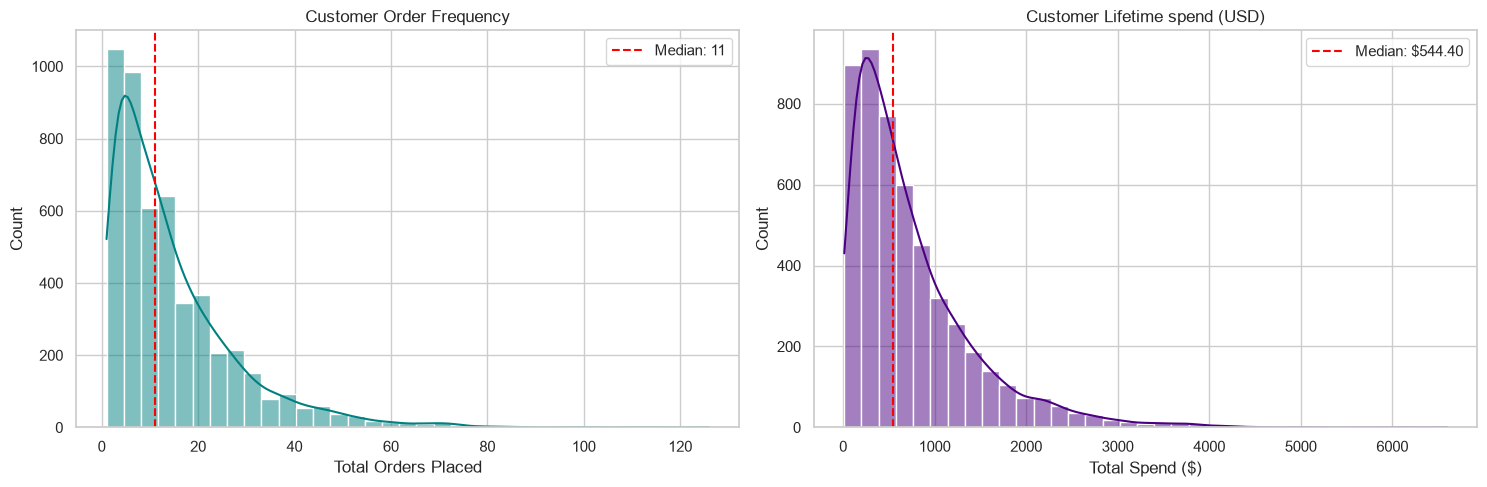

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Order Frequency
sns.histplot(customers['frequency'], bins=35, kde=True, ax=axes[0], color='teal')
axes[0].set_title('Customer Order Frequency')
axes[0].set_xlabel('Total Orders Placed')
axes[0].axvline(customers['frequency'].median(), color='red', linestyle='--', label=f"Median: {customers['frequency'].median():.0f}")
axes[0].legend()

# Total Spend
sns.histplot(customers['total_spend'], bins=35, kde=True, ax=axes[1], color='indigo')
axes[1].set_title('Customer Lifetime spend (USD)')
axes[1].set_xlabel('Total Spend ($)')
axes[1].axvline(customers['total_spend'].median(), color='red', linestyle='--', label=f"Median: ${customers['total_spend'].median():.2f}")
axes[1].legend()

plt.tight_layout()
plt.savefig('../report/figures/univariate_customer_frequency_spend.png', dpi=300)
plt.show()

### B. Customer Active Lifespan & Recency
We evaluate how many days elapsed between their signup and their latest purchase (`active_lifespan_days`), and the number of days since their latest purchase (`days_since_latest_order`). Recency helps us separate long-term dormant (churned) customers from newly acquired customers.

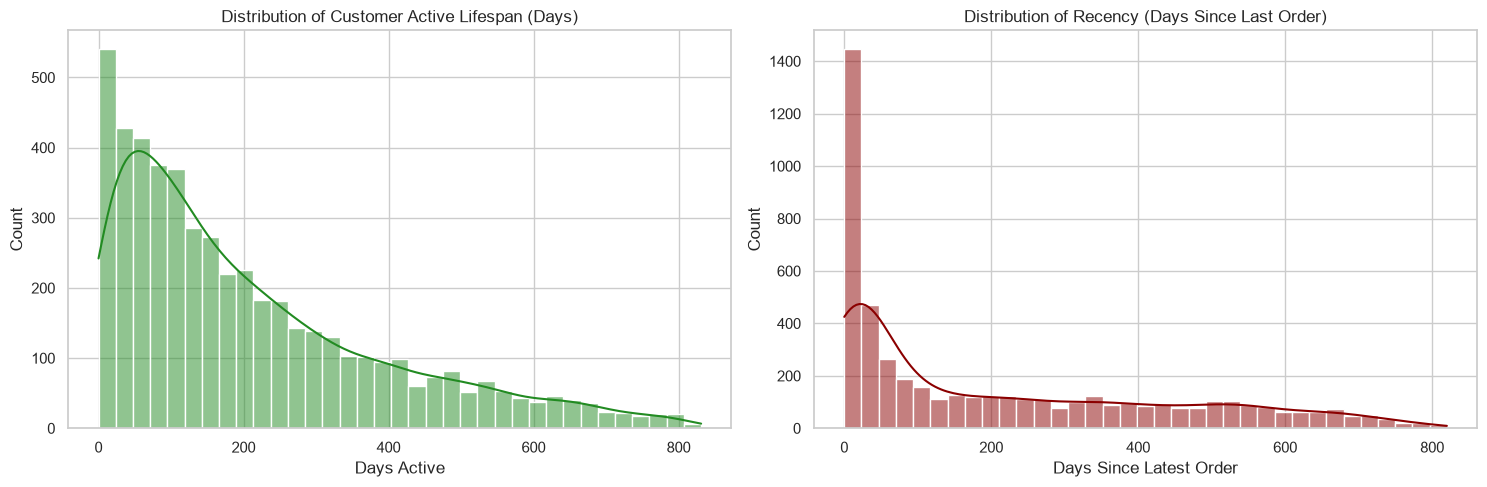

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Active Lifespan
sns.histplot(customers['active_lifespan_days'], bins=35, kde=True, ax=axes[0], color='forestgreen')
axes[0].set_title('Distribution of Customer Active Lifespan (Days)')
axes[0].set_xlabel('Days Active')

# Recency
sns.histplot(customers['days_since_latest_order'], bins=35, kde=True, ax=axes[1], color='darkred')
axes[1].set_title('Distribution of Recency (Days Since Last Order)')
axes[1].set_xlabel('Days Since Latest Order')

plt.tight_layout()
plt.savefig('../report/figures/univariate_customer_lifespan_recency.png', dpi=300)
plt.show()

## 5. Categorical Distributions & Proportions

### A. Customer Demographics (Gender, Age Group, Segment)
We review the demographics of our customer base to establish who the typical user is.

/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_36178/872426119.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='gender', data=customers, ax=axes[0], palette='pastel')
/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_36178/872426119.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='age_group', data=customers, ax=axes[1], palette='Set2', order=sorted(customers['age_group'].unique()))
/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_36178/872426119.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.count

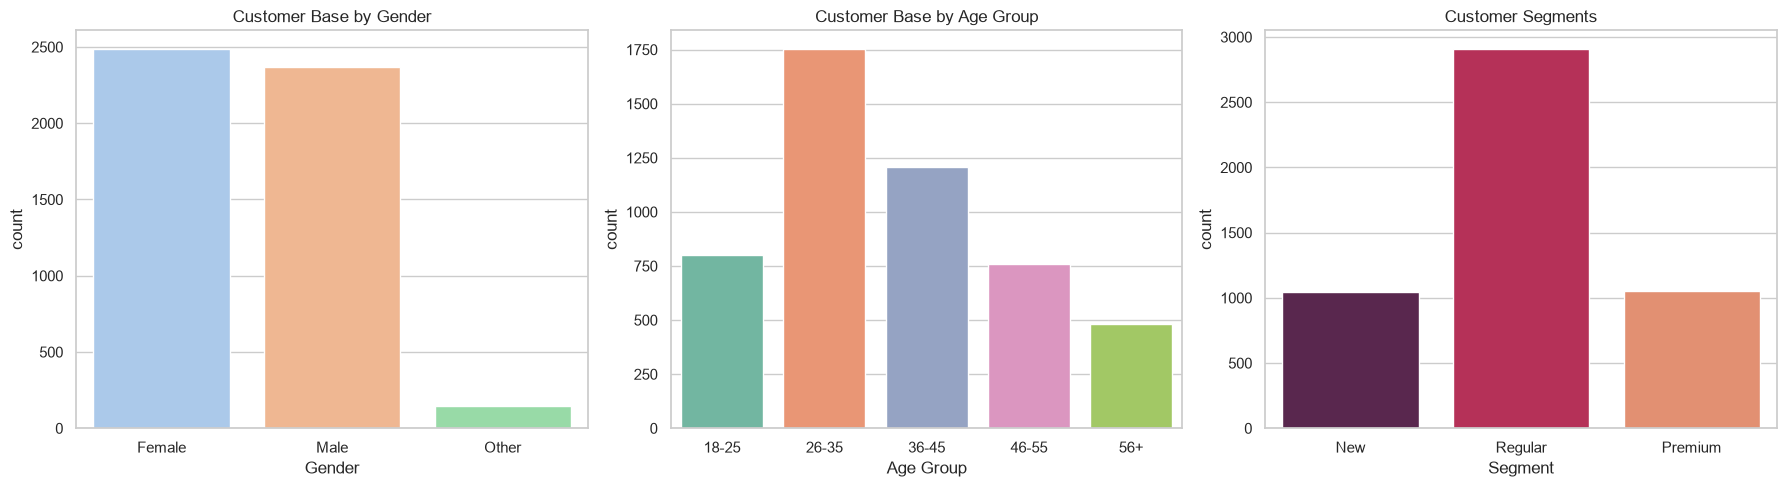

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Gender distribution
sns.countplot(x='gender', data=customers, ax=axes[0], palette='pastel')
axes[0].set_title('Customer Base by Gender')
axes[0].set_xlabel('Gender')

# Age Group distribution
sns.countplot(x='age_group', data=customers, ax=axes[1], palette='Set2', order=sorted(customers['age_group'].unique()))
axes[1].set_title('Customer Base by Age Group')
axes[1].set_xlabel('Age Group')

# Customer Segment
sns.countplot(x='customer_segment', data=customers, ax=axes[2], palette='rocket')
axes[2].set_title('Customer Segments')
axes[2].set_xlabel('Segment')

plt.tight_layout()
plt.savefig('../report/figures/univariate_customer_demographics.png', dpi=300)
plt.show()

### B. Geographic Distributions (State & City)
We audit the location data of our customer segments to check market concentrations.

/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_36178/2943818253.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='state', data=customers, ax=axes[0], order=customers['state'].value_counts().index, palette='mako')
/var/folders/sl/47y1_b4n2mgg2sd9h16kxdxm0000gn/T/ipykernel_36178/2943818253.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='city', data=customers, ax=axes[1], order=customers['city'].value_counts().index, palette='crest')


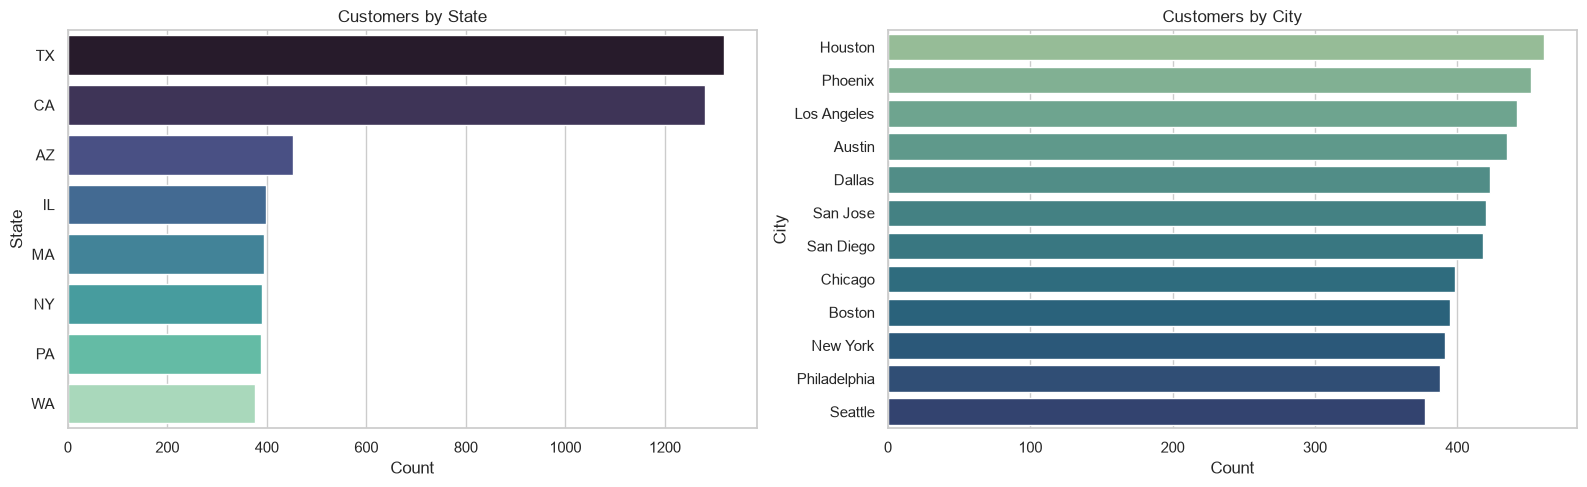

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# State Distribution
sns.countplot(y='state', data=customers, ax=axes[0], order=customers['state'].value_counts().index, palette='mako')
axes[0].set_title('Customers by State')
axes[0].set_xlabel('Count')
axes[0].set_ylabel('State')

# City Distribution
sns.countplot(y='city', data=customers, ax=axes[1], order=customers['city'].value_counts().index, palette='crest')
axes[1].set_title('Customers by City')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('City')

plt.tight_layout()
plt.savefig('../report/figures/univariate_customer_locations.png', dpi=300)
plt.show()

## Summary of Key Univariate Findings

1. **Highly Skewed Monetary Metrics**: The distribution of `order_value_usd` and customer `total_spend` is highly right-skewed. The log transformation normalizes this behavior, suggesting that we should use log-scale metrics for future regression modeling.
2. **Delays distribution**: Delayed orders exhibit an average delay of ~19 minutes (when positive), but can reach up to 130 minutes. The cumulative distribution (CDF) shows that roughly 90% of delays are under 30 minutes, indicating a heavy tail for extreme delays.
3. **High Churn Rate**: **53% of our customer base** is classified as behaviorally churned (>90 days of inactivity). This demonstrates a massive engagement issue.
4. **Geographic Concentration**: Over 50% of the customer base is concentrated in Texas (TX) and California (CA), with Dallas, Houston, Los Angeles, and San Jose being our largest urban markets.